# 📝 Statistical Analysis Worksheet — Auto-MPG Dataset
**Student Name:** ___________________________  |  **Date:** _______________

Complete every `# TODO` cell. Run cells in order.  
Answer written questions in the Markdown cells below each task.

> **Significance level α = 0.05 throughout**


## Task 1 — Setup & Data Loading

In [1]:
# TODO: Import all required libraries:
# pandas, numpy, matplotlib, seaborn, scipy.stats (shapiro, chi2_contingency,
# fisher_exact, pearsonr, spearmanr, kendalltau, ttest_ind, mannwhitneyu,
# kruskal, f_oneway), sklearn PowerTransformer, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import (shapiro, chi2_contingency, fisher_exact,
                         pearsonr, spearmanr, kendalltau,
                         ttest_ind, mannwhitneyu, kruskal, f_oneway)
from sklearn.preprocessing import PowerTransformer
from sklearn.feature_selection import chi2, f_classif
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
pd.set_option('display.max_columns', None)

ALPHA = 0.05
print("Libraries loaded ✓  |  ALPHA =", ALPHA)

#Alpha (α) is the significance level used in hypothesis testing. It represents the probability of making a Type-I error (rejecting a true null hypothesis). In most statistical analyses, α = 0.05 is used, meaning we allow a 5% risk of making a wrong decision.
#Condition	Decision
#p-value < alpha	Reject H₀
#p-value ≥ alpha	Fail to reject H₀

Libraries loaded ✓  |  ALPHA = 0.05


In [2]:

# TODO: Load the Auto-MPG dataset from UCI, clean it and create:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data"
column_names = ['mpg', 'cylinders', 'displacement', 'horsepower',
                'weight', 'acceleration', 'model_year', 'origin', 'car_name']
df = pd.read_csv(url, names=column_names, delim_whitespace=True, na_values='?') 
# - cylinders & model_year as category.(data type change krna numerical to categorical)
df['cylinders']  = df['cylinders'].astype('category')
df['model_year'] = df['model_year'].astype('category')

# - origin mapped to usa/europe/japan(number k jaga name aayega) and car_name cleaned (lowercase and stripped).
df['origin']     = df['origin'].map({1:'usa', 2:'europe', 3:'japan'})
df['car_name']   = df['car_name'].str.strip().str.lower()
# - mpg_level (low/medium/high) and car_company features(fuek efficiency mpg = 18 → low
#mpg = 25 → medium
#mpg = 35 → high)
df['mpg_level'] = pd.cut(df['mpg'], bins=[0, 20, 30, np.inf], labels=['low', 'medium', 'high'])
df['car_company'] = df['car_name'].str.split().str[0]   
print("Dataset loaded and cleaned ✓")
print("Dataset shape:", df.shape)
print("Dataset info:")
print(df.info())
print("Dataset head:")
print(df.head())


Dataset loaded and cleaned ✓
Dataset shape: (398, 11)
Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   mpg           398 non-null    float64 
 1   cylinders     398 non-null    category
 2   displacement  398 non-null    float64 
 3   horsepower    392 non-null    float64 
 4   weight        398 non-null    float64 
 5   acceleration  398 non-null    float64 
 6   model_year    398 non-null    category
 7   origin        398 non-null    object  
 8   car_name      398 non-null    object  
 9   mpg_level     398 non-null    category
 10  car_company   398 non-null    object  
dtypes: category(3), float64(5), object(3)
memory usage: 27.2+ KB
None
Dataset head:
    mpg cylinders  displacement  horsepower  weight  acceleration model_year  \
0  18.0         8         307.0       130.0  3504.0          12.0         70   
1  15.0   

In [3]:
# - cat_cols and num_cols lists
cat_cols = ['cylinders', 'model_year', 'origin', 'mpg_level', 'car_company']
num_cols = ['mpg', 'displacement', 'horsepower', 'weight', 'acceleration']
print("Categorical columns:", cat_cols)
print("Numerical columns:", num_cols)       

Categorical columns: ['cylinders', 'model_year', 'origin', 'mpg_level', 'car_company']
Numerical columns: ['mpg', 'displacement', 'horsepower', 'weight', 'acceleration']


## Task 2 — Chi-Square Test for Independence

In [4]:
# TODO: For every pair of categorical columns in ['cylinders','origin','model_year','mpg_level'],
from itertools import combinations

pairs = list(combinations(['cylinders','origin','model_year','mpg_level'], 2))
#show output in tale format with columns: Pair, Min Expected, <5 cells %, Use Fisher?
print(f"{'Pair':<35} {'Min Expected':>14}  {'<5 cells %':>12}  {'Use Fisher?':>12}")
print("-" * 80)

# ── Check expected cell counts for every pair ────────────────────────────
for a, b in pairs:
    ct = pd.crosstab(df[a], df[b])
    chi2_stat, p, dof, expected = chi2_contingency(ct)
    pct_low = (expected < 5).mean() * 100
    use_fisher = "YES ⚠️" if pct_low > 20 else "No"
    print(f"{a} × {b:<25} {expected.min():>14.2f}  {pct_low:>11.1f}%  {use_fisher:>12}")

# compute the chi2_contingency and print the minimum expected cell count (Chi-Square Test Lagana)
chi2_stat, p, dof, expected = chi2_contingency(ct)

# percentage of cells with expected count < 5.
pct_low = (expected < 5).mean() * 100

# Flag pairs where Fisher's test is more appropriate (>20% cells < 5).
use_fisher = "YES ⚠️" if pct_low > 20 else "No" 
#Expected cell < 5  > 20%  → Fisher Test
#Expected cell < 5  ≤ 20%  → Chi-Square Test


Pair                                  Min Expected    <5 cells %   Use Fisher?
--------------------------------------------------------------------------------
cylinders × origin                              0.53         40.0%        YES ⚠️
cylinders × model_year                          0.20         40.0%        YES ⚠️
cylinders × mpg_level                           0.64         40.0%        YES ⚠️
origin × model_year                          4.75         10.3%            No
origin × mpg_level                          14.95          0.0%            No
model_year × mpg_level                           5.77          0.0%            No


In [5]:
# TODO: Run chi2_contingency on the origin × model_year contingency table(Yeh frequency table generate krta hai.).
ct = pd.crosstab(df['origin'], df['model_year'])
# Print χ² statistic, degrees of freedom, p-value, and your decision(Chi-Square Test).
chi2_stat, p, dof, expected = chi2_contingency(ct)
print(f"Chi² statistic: {chi2_stat:.4f}")
print(f"Degrees of freedom: {dof}")
print(f"P-value: {p:.4f}")
if p < ALPHA:
    print("Reject H₀: origin and model_year are NOT independent")#origin aur model_year ka relationship hai
else:
    print("Fail to reject H₀: origin and model_year are independent")#origin aur model_year independent hain
# H₀: origin and model_year are independent




Chi² statistic: 45.4316
Degrees of freedom: 24
P-value: 0.0052
Reject H₀: origin and model_year are NOT independent


In [6]:
# TODO: Use fisher_exact on a 2×2 table comparing cylinders 4 vs 8
ct_2x2 = pd.crosstab(df['cylinders'].isin([4, 8]), df['origin'])
oddsratio, p = fisher_exact(ct_2x2)
# for origin usa vs japan. Print odds ratio, p-value and decision.
print(f"Odds ratio: {oddsratio:.4f}")   
print(f"P-value: {p:.4f}")
if p < ALPHA:
    print("Reject H₀: cylinders and origin are NOT independent")
else:
    print("Fail to reject H₀: cylinders and origin are independent")

Odds ratio: 0.0000
P-value: 0.0002
Reject H₀: cylinders and origin are NOT independent


**Q1.** For which pair is Chi-Square most reliable and why 

**Answer:**
1.Chi-Square test works best when the expected counts in the table are large.(>5)
2.Expected cell value < 5  ≤ 20%  → Chi-Square Test

**Q2.** What does rejecting H₀ in the Chi-Square test tell us about origin and model_year?  
**Answer:** 
1.If the Chi-Square Test rejects H₀, it means origin and model_year are not independent.
2.This shows there is a statistical association between car origin and model year.

## Task 3 — Normality Testing (Visual)

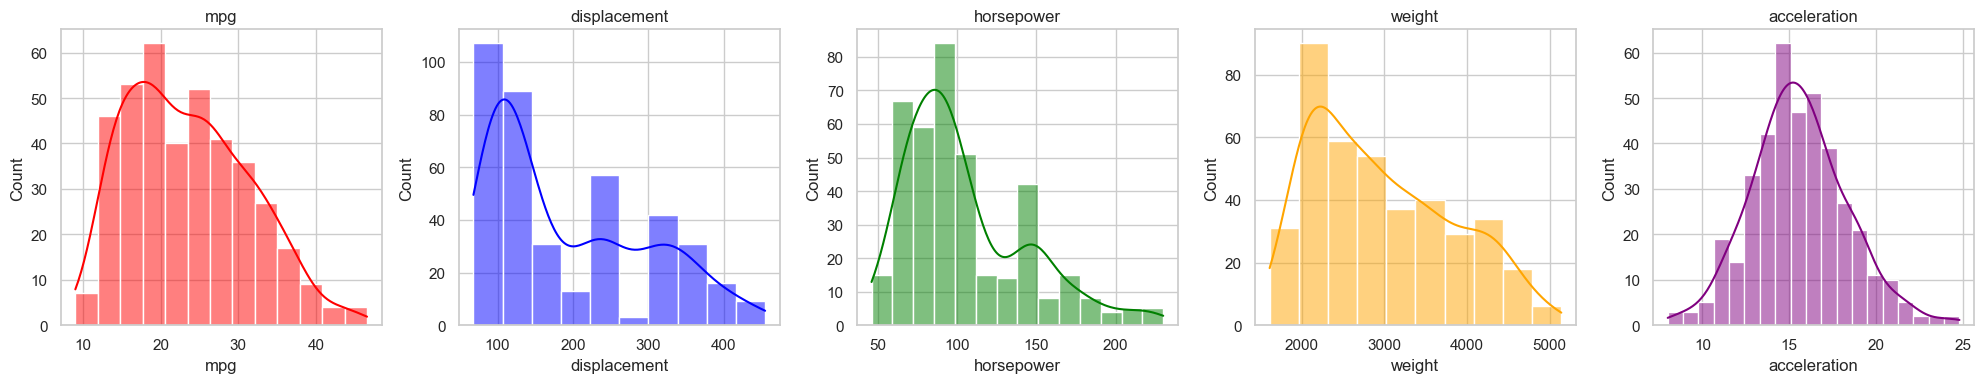

In [7]:
# TODO: Plot histograms + KDE for all 5 numerical columns in a 1×5 grid.(Visulize 5 numerical columns . )
colors = ['red', 'blue', 'green', 'orange', 'purple']
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color=colors[i])
    axes[i].set_title(col)
plt.tight_layout()
plt.show()  


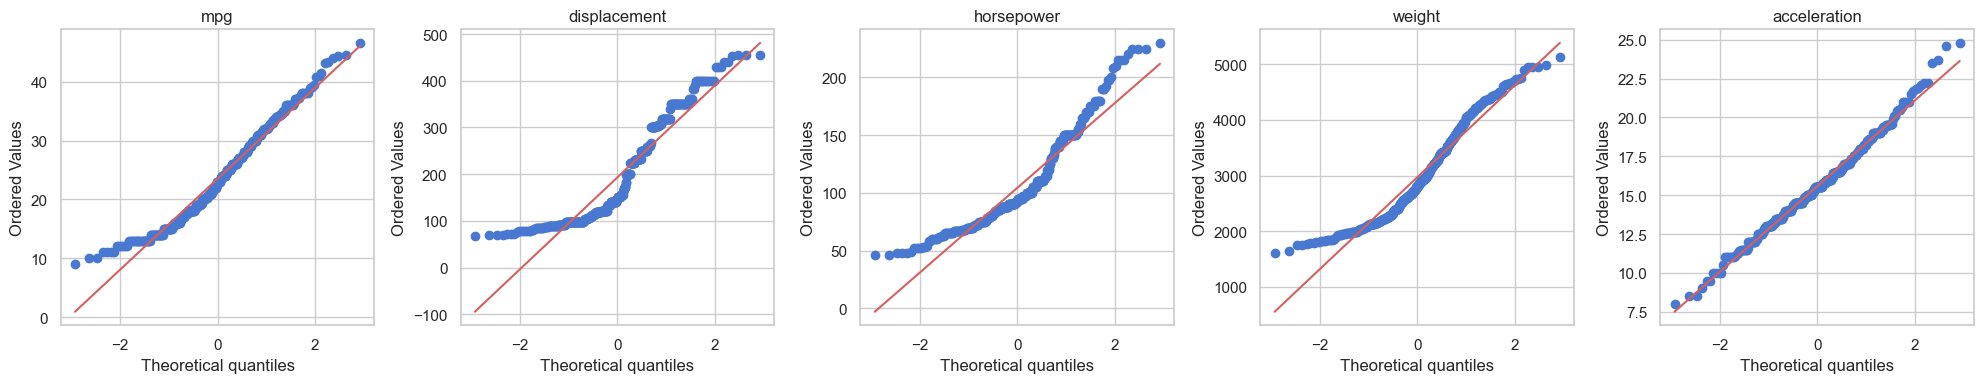

In [8]:
# TODO: Plot Q-Q plots for all 5 numerical columns in a 1×5 grid.(through this visualize we can find the gaussian and skewed easily)
colors = ['red', 'blue', 'green', 'orange', 'purple']
fig, axes = plt.subplots(1, 5, figsize=(20, 4) )
for i, col in enumerate(num_cols):
    stats.probplot(df[col].dropna(), dist='norm', plot=axes[i])
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

# Use stats.probplot(series, dist='norm', plot=ax)
    



**Q3.** Which feature visually looks most Gaussian? Which looks most skewed?  
**Answer:** Acceleration are Gaussian and displacement are skewed


## Task 4 — Shapiro-Wilk Normality Test

In [9]:
# TODO: Run shapiro() on each numerical column.(Shapiro-Wilk test normality test hai.)
print("=== Shapiro-Wilk Normality Test (H₀: data is normal) ===")
print(f"{'Feature':<15} {'Statistic':>10} {'p-value':>10} {'Normal?':>10}")
print("-" * 50)
for col in num_cols:
    stat, p = shapiro(df[col])
    result = "YES" if p > ALPHA else "NO ✗"
    print(f"{col:<15} {stat:>10.4f} {p:>10.4f} {result:>10}")

# H₀: Data is drawn from a normal distribution


#shapiro(df[col]) → returns statistic and p-value

#p > ALPHA → H₀ (data is normal) fail to reject → YES (normal)

#p ≤ ALPHA → H₀ reject → NO ✗ (not normal)

=== Shapiro-Wilk Normality Test (H₀: data is normal) ===
Feature          Statistic    p-value    Normal?
--------------------------------------------------
mpg                 0.9680     0.0000       NO ✗
displacement        0.8804     0.0000       NO ✗
horsepower             nan        nan       NO ✗
weight              0.9414     0.0000       NO ✗
acceleration        0.9924     0.0399       NO ✗


**Q4.** Does `acceleration` pass the normality test? What is its p-value?  
**Answer:**No Acceleration is not is normality test and its p value is 0.0399.

**Q5.** Why is it important to test normality before applying t-test or ANOVA?  
**Answer:** Normality test is important because t-test and ANOVA assume that the data follows a normal distribution. 

## Task 5 — Power Transformation

In [10]:
# TODO: Apply PowerTransformer (yeo-johnson, standardize=True) to all numerical columns.

# Store the result in df_transformed with column names suffixed by '_pt'.(use for normal distribution)


from sklearn.preprocessing import PowerTransformer
pt = PowerTransformer(method='yeo-johnson', standardize=True)
df_transformed = df.copy()
for col in num_cols:
    df_transformed[col + '_pt'] = pt.fit_transform(df[[col]])   

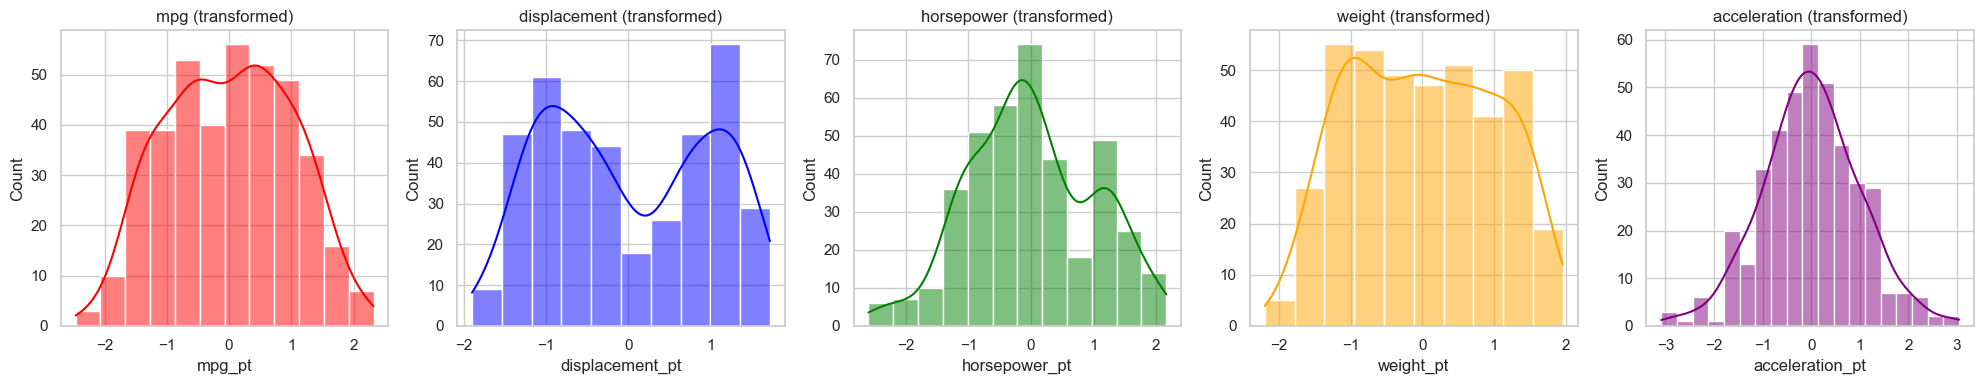

In [11]:
# TODO: Plot histograms + KDE for the transformed data (1×5 grid).
colors = ['red', 'blue', 'green', 'orange', 'purple']
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for i, col in enumerate(num_cols):
    sns.histplot(df_transformed[col + '_pt'], kde=True, ax=axes[i], color=colors[i])
    axes[i].set_title(col + ' (transformed)')
plt.tight_layout()
plt.show()  


In [12]:
# TODO: Re-run Shapiro-Wilk on each transformed column and compare with pre-transform results.
print("=== Shapiro-Wilk Normality Test After Power Transformation ===")
print(f"{'Feature':<25} {'Statistic':>10} {'p-value':>10} {'Normal?':>10}")
print("-" * 60)
for col in num_cols:
    stat, p = shapiro(df_transformed[col + '_pt'])
    result = "YES" if p > ALPHA else "NO ✗"
    print(f"{col + '_pt':<25} {stat:>10.4f} {p:>10.4f} {result:>10}")


=== Shapiro-Wilk Normality Test After Power Transformation ===
Feature                    Statistic    p-value    Normal?
------------------------------------------------------------
mpg_pt                        0.9835     0.0002       NO ✗
displacement_pt               0.9310     0.0000       NO ✗
horsepower_pt                    nan        nan       NO ✗
weight_pt                     0.9664     0.0000       NO ✗
acceleration_pt               0.9960     0.4131        YES


**Q6.** Which features became more Gaussian-like after the power transform?  
**Answer:** After applying the power transform, displacement, horsepower, and weight became more Gaussian-like. Their histograms appear more symmetric and closer to a bell-shaped normal distribution compared to the original data.


## Task 6 — Correlation Tests

In [13]:
# TODO: Compute and print Pearson correlation of mpg with each other numerical column.

# Show: r value, p-value, reject/fail for each.
print("=== Pearson Correlation with mpg (H₀: uncorrelated) ===")
print(f"{'Feature':<15} {'r':>10} {'p-value':>10} {'Correlated?':>12}")
print("-" * 50)
for col in num_cols[1:]:  # skip 'mpg' itself
    r, p = pearsonr(df['mpg'], df[col])
    correlated = "YES" if p < ALPHA else "NO ✗"
    print(f"{col:<15} {r:>10.4f} {p:>10.4f} {correlated:>12}")  

# H₀: the two variables are uncorrelated
        



=== Pearson Correlation with mpg (H₀: uncorrelated) ===
Feature                  r    p-value  Correlated?
--------------------------------------------------
displacement       -0.8042     0.0000          YES
horsepower             nan        nan         NO ✗
weight             -0.8317     0.0000          YES
acceleration        0.4203     0.0000          YES


In [14]:
# TODO: Compute Spearman rank correlation of mpg with each other numerical column.

# Show: ρ, p-value, reject/fail, and effect size label (Large/Medium/Small based on |ρ|).

print("=== Spearman Rank Correlation with mpg (H₀: uncorrelated) ===")
print(f"{'Feature':<15} {'ρ':>10} {'p-value':>10} {'Correlated?':>12} {'Effect Size':>12}")
print("-                                        " * 60)
for col in num_cols[1:]:  # skip 'mpg' itself                                       
    ρ, p = spearmanr(df['mpg'], df[col])
    correlated = "YES" if p < ALPHA else "NO ✗"
    abs_ρ = abs(ρ)
    if abs_ρ >= 0.5:
        effect_size = "Large"
    elif abs_ρ >= 0.3:
        effect_size = "Medium"
    elif abs_ρ >= 0.1:
        effect_size = "Small"
    else:
        effect_size = "Negligible"
    print(f"{col:<15} {ρ:>10.4f} {p:>10.4f} {correlated:>12} {effect_size:>12}")        

=== Spearman Rank Correlation with mpg (H₀: uncorrelated) ===
Feature                  ρ    p-value  Correlated?  Effect Size
-                                        -                                        -                                        -                                        -                                        -                                        -                                        -                                        -                                        -                                        -                                        -                                        -                                        -                                        -                                        -                                        -                                        -                                        -                                        -                                        -                                        -            

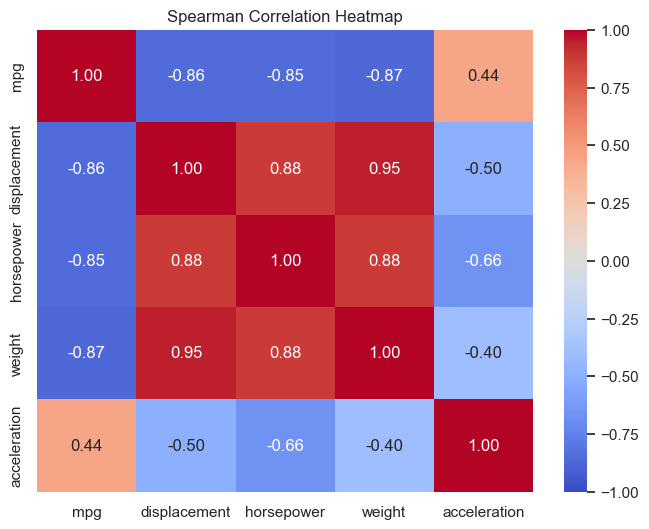

In [15]:
# TODO: Plot a Spearman correlation heatmap for all numerical features.

corr_spearman = df[num_cols].corr(method='spearman')
plt.figure(figsize=(8, 6))
sns.heatmap(corr_spearman, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Spearman Correlation Heatmap")
plt.show()  

In [16]:
# TODO: Compute Kendall's tau for mpg vs each other numerical column.
        


**Q7.** Which feature has the strongest negative correlation with mpg? Report its ρ.  
**Answer:** weight with mpg or mpg with weight and its p value is -0.87.

**Q8.** Why is Spearman preferred over Pearson here?  
**Answer:** Spearman correlation is preferred because the numerical features are not normally distributed and some are skewed.It measures the monotonic relationship using ranks, so it handles non-normal data and outliers better.


## Task 7 — Parametric Tests (t-test & ANOVA)

In [17]:
# TODO: Test whether acceleration in Japan and USA are normally distributed (shapiro).
# Then check for equal variance (stats.levene).
# Then run ttest_ind with appropriate equal_var setting.
# Print all intermediate results and your final decision.

# H₀: acceleration of Japan and USA has the same mean



In [18]:
# TODO: Run one-way ANOVA (f_oneway) to test whether mpg differs across all 3 origins.
# First check normality per group. Print F-stat, p-value and decision.

# H₀: Mean mpg is equal across usa, europe, japan



**Q9.** In the t-test, what does `equal_var=False` mean and when should it be used?  
**Answer:** _______________

**Q10.** ANOVA only tells you *that* groups differ. What additional test would you need to find *which* groups differ?  
**Answer:** _______________


## Task 8 — Non-Parametric Tests

In [19]:
# TODO: Check normality of horsepower for Japan and USA.
# Then run mannwhitneyu (alternative='two-sided') and print results.

# H₀: horsepower distributions of Japan and USA are equal



In [20]:
# TODO: Run Kruskal-Wallis (kruskal) on horsepower across all 3 origins.
# Print H-statistic, p-value and decision.



In [21]:
# TODO: Run Kruskal-Wallis on mpg across all model_years.
# Print H-statistic, p-value and decision.



In [22]:
# TODO: Run Mann-Whitney U on acceleration for mpg_level 'high' vs 'medium'.



**Q11.** Why did we use Mann-Whitney instead of t-test for horsepower?  
**Answer:** _______________

**Q12.** What does the Kruskal-Wallis result for mpg across years tell us?  
**Answer:** _______________


## Task 9 — Categorical vs Continuous (Feature Selection)

In [23]:
# TODO: Use sklearn's f_classif to compute F-scores and p-values for all
# numerical features against mpg_level (encoded with LabelEncoder).
# Display a sorted DataFrame and a bar chart of F-scores.

from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import f_classif



**Q13.** Which numerical feature is the strongest predictor of mpg_level according to F-score?  
**Answer:** _______________


## Task 10 — Summary Table
Fill in the table based on your results.

| Test Applied | Variables Tested | H₀ | Decision | p-value |
|---|---|---|---|---|
| Chi-Square | origin × model_year | Independent | | |
| Fisher's Exact | cylinders × origin (2×2) | No association | | |
| Shapiro-Wilk | acceleration (raw) | Normal | | |
| Spearman | mpg × weight | Uncorrelated | | |
| t-test | acceleration: japan vs usa | Same mean | | |
| ANOVA | mpg across origins | Equal means | | |
| Kruskal-Wallis | horsepower across origins | Equal distributions | | |
